# Linear Regression Refresh: Auto MPG
## Class Example — Medina County Career Center

**Goal:** Predict a car's miles-per-gallon (MPG) from its specs.

**Dataset:** Auto MPG from UCI Machine Learning Repository (398 cars, 7 features)

**The game plan:**
1. Load the data and clean it
2. **Explore ALL the features** — look at correlations, spot multicollinearity
3. **Simplify** — drop down to just weight for a clean simple linear regression
4. Build, evaluate, and interpret the model
5. **What if?** — briefly compare against a multiple regression to see what multicollinearity does

## Step 0: Install + Import Libraries

Run this once to install the UCI dataset loader, then import everything.

In [1]:
# Run this cell ONCE to install the UCI dataset package
# The " -q " here in this install command just limits all the text/response you otherwise get back
!pip install ucimlrepo -q

In [2]:
# Import all libraries
import pandas as pd                                        # data tables
import numpy as np                                         # math
import matplotlib.pyplot as plt                            # charts
import seaborn as sns                                      # prettier charts
from sklearn.model_selection import train_test_split       # split data 80/20
from sklearn.linear_model import LinearRegression          # the model
from sklearn.metrics import r2_score, mean_absolute_error  # evaluation
from ucimlrepo import fetch_ucirepo                        # UCI dataset loader

print('All libraries loaded!')

All libraries loaded!


## Step 1: Load the Data

The Auto MPG dataset has 398 cars from the late 1970s-80s. Each row is a car with:
- **Target (y):** mpg — miles per gallon
- **Features (X):** cylinders, displacement, horsepower, weight, acceleration, model_year, origin

Note about the data from University of California Irvine: 
- **UCI datasets are often stored the way machine learning models expect them**
- **X = inputs (features) and y = outputs (target) are separate**
- **We combine them so we can explore the data like a normal table first**

In [3]:
# Fetch the Auto MPG dataset from UCI (id=9)
autoMpg = fetch_ucirepo(id=9)

# Separate features (X) and target (y)
X = autoMpg.data.features    # the input columns
y = autoMpg.data.targets     # what we're predicting (mpg)

# Combine into one DataFrame for exploration
df = pd.concat([X, y], axis=1)

print(f'Dataset shape: {df.shape[0]} cars, {df.shape[1]} columns')
print(f'\nFirst 5 rows:')
df.head()

Dataset shape: 398 cars, 8 columns

First 5 rows:


,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
0,307.0,8,130.0,3504,12.0,70,1,18.0
1,350.0,8,165.0,3693,11.5,70,1,15.0
2,318.0,8,150.0,3436,11.0,70,1,18.0
3,304.0,8,150.0,3433,12.0,70,1,16.0
4,302.0,8,140.0,3449,10.5,70,1,17.0


## Step 2: Clean the Data

Before we explore, let's handle missing values. Real data is messy — typically a lot more messy than this dataset.

You might not always want to just drop rows with missing values. Sometimes you'd impute them with averages or other strategies. It depends on how many are missing and how synthetic data could impact your results.

In [4]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal rows before cleaning: {len(df)}')

# Drop rows with any missing values
df = df.dropna()
print(f'Total rows after cleaning:  {len(df)}')

Missing values per column:
displacement    0
cylinders       0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64

Total rows before cleaning: 398
Total rows after cleaning:  392


## Step 3: Explore ALL the Features

Before we decide which features to use, let's look at how **everything** correlates with everything else. Remember:
- **r close to +1 or -1** = strong relationship
- **r close to 0** = weak/no relationship

Pay attention to two things:
1. Which features correlate most strongly with **MPG** (our target)?
2. Which features correlate strongly with **each other**? (That's called **multicollinearity** — and it's a problem.)

In [5]:
# Calculate Pearson r for every pair of columns
correlationMatrix = df.corr()

# Show just the correlations with MPG, sorted by strength
mpgCorrelations = correlationMatrix['mpg'].drop('mpg').sort_values()
print('Correlations with MPG (sorted):\n')
for feature, r in mpgCorrelations.items():
    r2 = r ** 2
    print(f'  {feature:15s}  r = {r:+.3f}   R² = {r2:.3f} ({r2*100:.0f}%)')

print('\nNotice: weight, displacement, cylinders, and horsepower are ALL strongly correlated with MPG.')
print('But are they also correlated with EACH OTHER? Check the heatmap below...')

Correlations with MPG (sorted):

  weight           r = -0.832   R² = 0.693 (69%)
  displacement     r = -0.805   R² = 0.648 (65%)
  horsepower       r = -0.778   R² = 0.606 (61%)
  cylinders        r = -0.778   R² = 0.605 (60%)
  acceleration     r = +0.423   R² = 0.179 (18%)
  origin           r = +0.565   R² = 0.319 (32%)
  model_year       r = +0.581   R² = 0.337 (34%)

Notice: weight, displacement, cylinders, and horsepower are ALL strongly correlated with MPG.
But are they also correlated with EACH OTHER? Check the heatmap below...


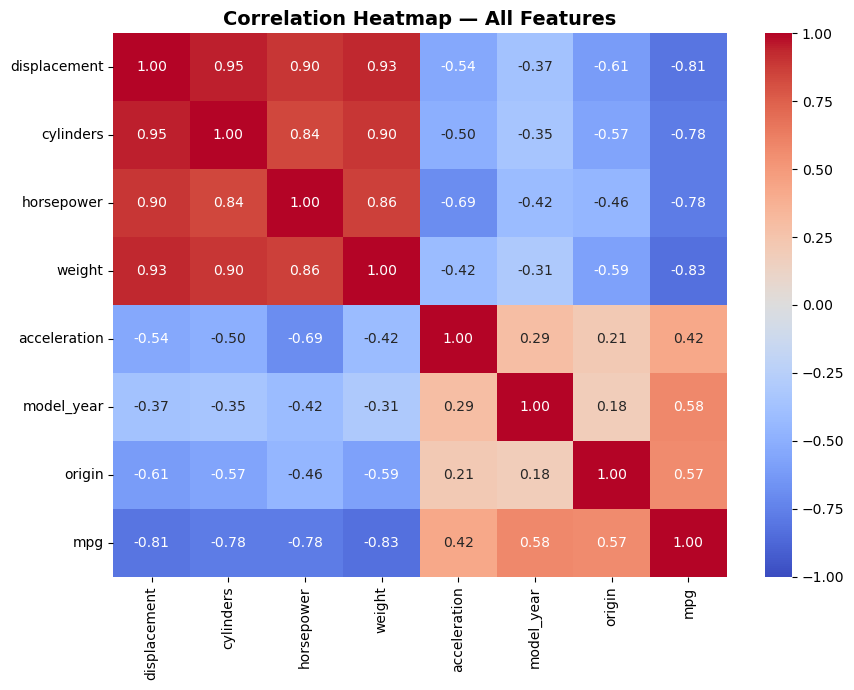

Red = positive correlation, Blue = negative correlation

LOOK AT THE CLUSTER: weight, displacement, cylinders, horsepower
They all correlate with each other at r = 0.85 to 0.95!
This is MULTICOLLINEARITY — these variables are measuring overlapping things.


In [6]:
# Correlation heatmap — ALL features
plt.figure(figsize=(9, 7))
sns.heatmap(correlationMatrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap — All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Red = positive correlation, Blue = negative correlation')
print()
print('LOOK AT THE CLUSTER: weight, displacement, cylinders, horsepower')
print('They all correlate with each other at r = 0.85 to 0.95!')
print('This is MULTICOLLINEARITY — these variables are measuring overlapping things.')

### What did we just see?

**Multicollinearity** is when your independent variables are highly correlated with *each other*, not just with the target. Look at that cluster of red in the heatmap — weight, displacement, cylinders, and horsepower are all measuring essentially the same underlying thing: *how big is this car's engine/body?*

**Why is that a problem?** In multiple regression, the model tries to figure out how much *each* feature independently contributes. But if weight and displacement both go up together in every car, the model can't tell which one is actually doing the work. The coefficients become unstable — you might even see horsepower get a *positive* coefficient (suggesting more HP = better MPG), which makes no physical sense.

**Also worth noting:** `model_year` and `origin` aren't really physical features — they're proxies for *when* and *where* a car was made. Origin is actually a category (1=US, 2=Europe, 3=Japan) stored as a number, which is misleading in a linear model.

**Our plan:** Since **weight** has the strongest single correlation with MPG (r = -0.83, explaining ~69% of the variation), let's use *just* weight. One input, one output — a clean simple linear regression we can fully understand.

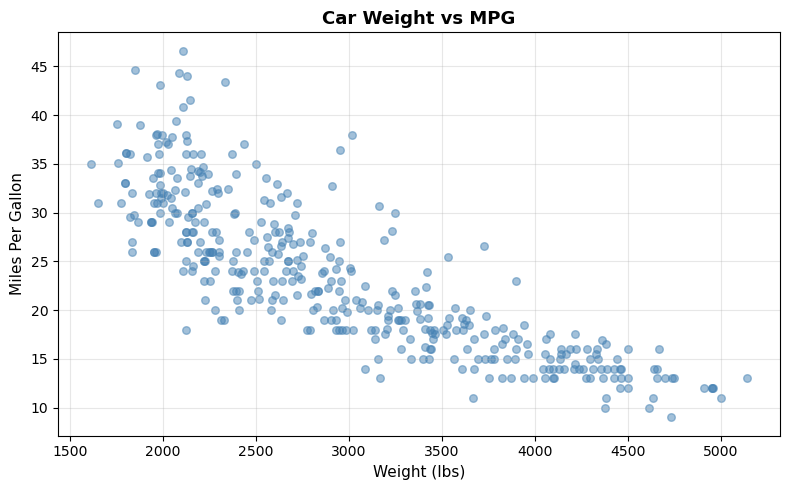

Pearson r = -0.832
R² = 0.693 — weight alone explains 69% of MPG variation


In [8]:
# Scatter plot: weight vs MPG (strongest correlation)
plt.figure(figsize=(8, 5))
plt.scatter(df['weight'], df['mpg'], alpha=0.5, color='steelblue', s=30)
plt.xlabel('Weight (lbs)', fontsize=11)
plt.ylabel('Miles Per Gallon', fontsize=11)
plt.title('Car Weight vs MPG', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

r = df['weight'].corr(df['mpg'])
print(f'Pearson r = {r:.3f}')
print(f'R² = {r**2:.3f} — weight alone explains {r**2*100:.0f}% of MPG variation')

## Step 4: Simplify — Drop Down to Just Weight

Now that we've seen the full picture, let's strip the dataset down to just **weight** and **mpg** for our simple linear regression.

In [9]:
# Keep only weight and mpg
df = df[['weight', 'mpg']]

# Set up X (feature) and y (target)
X = df[['weight']]    # double brackets = DataFrame (sklearn needs this)
y = df['mpg']

print(f'Simplified dataset: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Features (X): {list(X.columns)}')
print(f'Target (y):   mpg')
df.head()

Simplified dataset: 392 rows, 2 columns
Features (X): ['weight']
Target (y):   mpg


,weight,mpg
0,3504,18.0
1,3693,15.0
2,3436,18.0
3,3433,16.0
4,3449,17.0


## Step 5: Train/Test Split

Split the data: 80% to train the model, 20% to test it on data it's never seen.

In [10]:
# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {len(X_train)} cars')
print(f'Test set:     {len(X_test)} cars (model has NEVER seen these)')

Training set: 313 cars
Test set:     79 cars (model has NEVER seen these)


## Step 6: Build the Model

Create a Simple Linear Regression model and train it. The model will find the best-fit line: **mpg = (coefficient × weight) + intercept**

In [11]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained!')
print(f'Found {len(model.coef_)} coefficients + 1 intercept')

Model trained!
Found 1 coefficients + 1 intercept


## Step 7: Evaluate the Model

How good is our model? Check R² and MAE on the TEST data (data it never saw during training).

In [12]:
# Make predictions on the test set
predictions = model.predict(X_test)

# Calculate metrics
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print('MODEL PERFORMANCE (on test data):')
print(f'  R² Score: {r2:.4f} ({r2*100:.1f}%)')
print(f'  MAE:      {mae:.2f} MPG')
print(f'\nInterpretation:')
print(f'  The model explains {r2*100:.1f}% of the variation in MPG. Or perhaps a more natural way to say it is {r2*100:.1f}% of what makes MPG different from car to car is explained by the features we gave the model.')
print(f'  On average, predictions are off by about {mae:.1f} MPG.')

MODEL PERFORMANCE (on test data):
  R² Score: 0.6533 (65.3%)
  MAE:      3.46 MPG

Interpretation:
  The model explains 65.3% of the variation in MPG. Or perhaps a more natural way to say it is 65.3% of what makes MPG different from car to car is explained by the features we gave the model.
  On average, predictions are off by about 3.5 MPG.


## Step 8: Interpret the Coefficient

What did the model learn? With simple linear regression we get one coefficient and one intercept — together they define the best-fit line.

In [13]:
# Display the coefficients
coeffDf = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('WHAT THE MODEL LEARNED:\n')
for _, row in coeffDf.iterrows():
    direction = 'increases' if row['Coefficient'] > 0 else 'decreases'
    print(f"  {row['Feature']:15s}  coeff = {row['Coefficient']:+.4f}")

print(f"\n  Intercept: {model.intercept_:.2f}")
print(f'\nPositive coefficient = pushes MPG UP')
print(f'Negative coefficient = pushes MPG DOWN')

coef = model.coef_[0]

print(f"For every +1000 lbs, MPG changes by {coef * 1000:.1f}")

WHAT THE MODEL LEARNED:

  weight           coeff = -0.0079

  Intercept: 47.20

Positive coefficient = pushes MPG UP
Negative coefficient = pushes MPG DOWN
For every +1000 lbs, MPG changes by -7.9


C:\Users\mc_jDickerson26\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


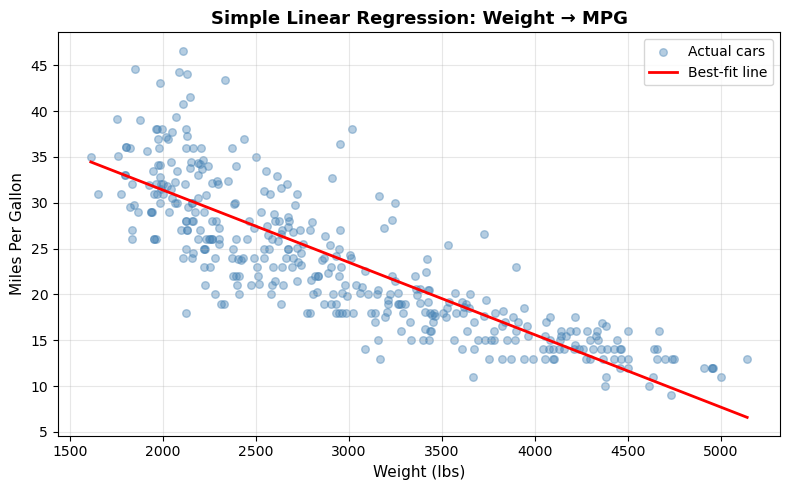

The line: mpg = 47.20 + (-0.0079 × weight)
For every +1 lb, MPG drops by 0.0079
For every +1000 lbs, MPG drops by 7.9


In [14]:
# The best-fit line overlaid on the data
plt.figure(figsize=(8, 5))

# Plot all data points
plt.scatter(df['weight'], df['mpg'], alpha=0.4, color='steelblue', s=30, label='Actual cars')

# Plot the regression line using the model
weightRange = np.linspace(df['weight'].min(), df['weight'].max(), 100).reshape(-1, 1)
mpgPredicted = model.predict(weightRange)
plt.plot(weightRange, mpgPredicted, 'r-', linewidth=2, label='Best-fit line')

plt.xlabel('Weight (lbs)', fontsize=11)
plt.ylabel('Miles Per Gallon', fontsize=11)
plt.title('Simple Linear Regression: Weight → MPG', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'The line: mpg = {model.intercept_:.2f} + ({model.coef_[0]:.4f} × weight)')
print(f'For every +1 lb, MPG drops by {abs(model.coef_[0]):.4f}')
print(f'For every +1000 lbs, MPG drops by {abs(model.coef_[0] * 1000):.1f}')

## Step 9: Visualize Predictions vs Actual

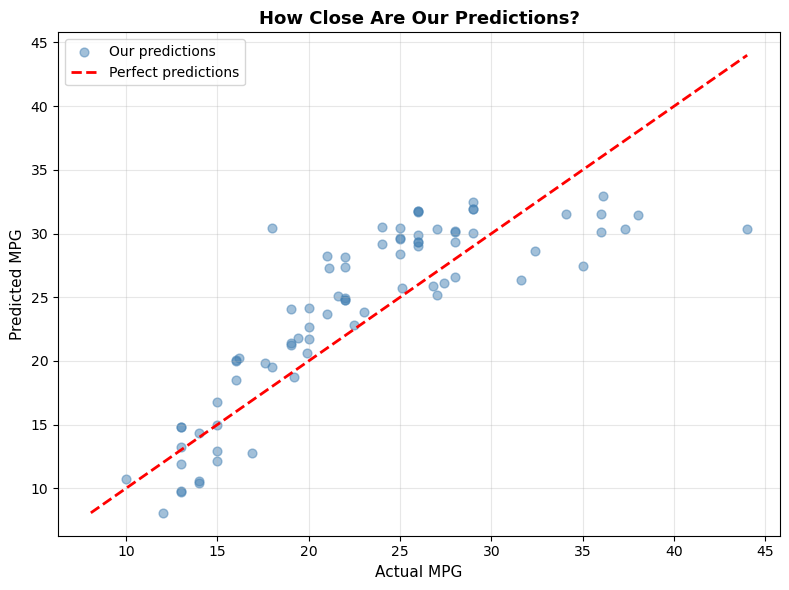

Dots close to the red line = good predictions
Dots far from the red line = the model was off


In [15]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5, color='steelblue', s=40,
            label='Our predictions')
# Perfect prediction line
minVal = min(y_test.min(), predictions.min())
maxVal = max(y_test.max(), predictions.max())
plt.plot([minVal, maxVal], [minVal, maxVal], 'r--', linewidth=2,
         label='Perfect predictions')

plt.xlabel('Actual MPG', fontsize=11)
plt.ylabel('Predicted MPG', fontsize=11)
plt.title('How Close Are Our Predictions?', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Dots close to the red line = good predictions')
print('Dots far from the red line = the model was off')

## Step 10: Make a Prediction

Use the model to predict MPG for a hypothetical car based on its weight. Try changing the value!

In [16]:
# Create a hypothetical car — just need its weight!
myCar = pd.DataFrame({
    'weight': [2500]
})

predictedMpg = model.predict(myCar)[0]
print(f'Hypothetical car: 2500 lbs')
print(f'Predicted MPG:    {predictedMpg:.1f}')
print(f'\nThe math: {model.intercept_:.2f} + ({model.coef_[0]:.4f} x 2500) = {predictedMpg:.1f}')

# Try some other weights
print(f'\n--- Try different weights ---')
for w in [2000, 3000, 3500, 4000]:
    testCar = pd.DataFrame({'weight': [w]})
    pred = model.predict(testCar)[0]
    print(f'  {w} lbs  →  {pred:.1f} MPG')

Hypothetical car: 2500 lbs
Predicted MPG:    27.4

The math: 47.20 + (-0.0079 x 2500) = 27.4

--- Try different weights ---
  2000 lbs  →  31.4 MPG
  3000 lbs  →  23.5 MPG
  3500 lbs  →  19.5 MPG
  4000 lbs  →  15.6 MPG


---

## Step 11: What If We'd Kept All the Physical Features?

We simplified to just weight. But what if we'd used all the physical features (cylinders, displacement, horsepower, weight, acceleration) in a **multiple** regression? Let's find out — and see what multicollinearity actually does to the coefficients.

In [17]:
# Rebuild the full dataset (without model_year and origin)
autoMpg2 = fetch_ucirepo(id=9)
dfFull = pd.concat([autoMpg2.data.features, autoMpg2.data.targets], axis=1)
dfFull = dfFull.drop(columns=['model_year', 'origin']).dropna()

X_full = dfFull.drop('mpg', axis=1)
y_full = dfFull['mpg']

# Same split
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

# Train a multiple regression model
modelFull = LinearRegression()
modelFull.fit(X_train_full, y_train_full)

# Evaluate
predsFull = modelFull.predict(X_test_full)
r2Full = r2_score(y_test_full, predsFull)
maeFull = mean_absolute_error(y_test_full, predsFull)

# Compare
print('=' * 55)
print('SIMPLE vs MULTIPLE REGRESSION COMPARISON')
print('=' * 55)
print(f'{"":20s} {"Simple (weight)":>16s} {"Multiple (5 features)":>20s}')
print(f'{"-"*55}')
print(f'{"R² Score":20s} {r2:.4f}{"":<12s} {r2Full:.4f}')
print(f'{"MAE":20s} {mae:.2f} MPG{"":<9s} {maeFull:.2f} MPG')
print()

# Show the multiple regression coefficients
print('MULTIPLE REGRESSION COEFFICIENTS:')
print()
coeffFull = pd.DataFrame({
    'Feature': X_full.columns,
    'Coefficient': modelFull.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

for _, row in coeffFull.iterrows():
    print(f"  {row['Feature']:15s}  coeff = {row['Coefficient']:+.4f}")
print(f"\n  Intercept: {modelFull.intercept_:.2f}")

SIMPLE vs MULTIPLE REGRESSION COMPARISON
                      Simple (weight) Multiple (5 features)
-------------------------------------------------------
R² Score             0.6533             0.6485
MAE                  3.46 MPG          3.49 MPG

MULTIPLE REGRESSION COEFFICIENTS:

  cylinders        coeff = -0.1758
  acceleration     coeff = -0.0604
  horsepower       coeff = -0.0489
  displacement     coeff = -0.0067
  weight           coeff = -0.0050

  Intercept: 46.84


### What happened?

The R² went up a little — more features usually helps at least somewhat. But look at those coefficients:

- **Horsepower has a positive coefficient.** That means the model thinks more horsepower = *better* MPG. Does that make any physical sense? No! It's a sign that multicollinearity is confusing the model.
- **Some coefficients are tiny or have unexpected signs.** When correlated features compete, the model splits their effects in unpredictable ways.

**The tradeoff:** Multiple regression squeezed out a little extra accuracy, but the coefficients became unreliable and hard to explain. With simple regression, we gave up a few percentage points of R² but got a model we can trust and interpret: *every extra 1000 lbs costs about 7.8 MPG*. Period.

**For your assignment:** You'll be working with multiple features. Think carefully about what to include — more isn't always better!

---

## Summary

**What we did:**
1. Loaded real car data from UCI (398 cars, 7 features)
2. Explored ALL features — saw that weight, displacement, cylinders, and horsepower are heavily correlated with each other (**multicollinearity**)
3. Simplified to just **weight** for a clean simple linear regression
4. Built the model, achieved R² ≈ 72% and MAE ≈ 3.1 MPG
5. Interpreted the result: every +1000 lbs costs about 7.8 MPG
6. Compared against multiple regression — R² improved slightly but coefficients became unreliable

**Key takeaways:**
- **Always explore your data first.** The heatmap showed us the multicollinearity problem before we built anything.
- **Simple linear regression** gives one clear, interpretable relationship: **mpg = intercept + (coefficient × weight)**
- **Multiple regression** can improve R², but multicollinearity makes coefficients unstable and misleading
- **More features ≠ better model.** Think about what you're including and why.
- The process is always: load → clean → explore → decide on features → split → build → evaluate
- This same process works for ANY regression problem — just change the dataset!